In [25]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from scipy.linalg import eigh

data = load_breast_cancer()
X = data.data
y = data.target
print(y) 
def clases(Y):
    elementos = []
    for y in Y:
        if y not in elementos:
            elementos.append(y)
    return elementos
clases = clases(y)
print(clases)
k = len(clases)
medias_k = [0]*k
for i,c in enumerate(clases):
    print(f"clase: {c} ")
    mascara = (y == c)
    medias_k[i] = X[mascara].mean(axis=0)
print(f"medias_k: {medias_k}\n")
u = X.mean(axis=0)
print(u)
m,n = X.shape
print(f"m,n {m}  {n} \n")
SW = np.zeros((n,n))
for i,c in enumerate(clases):   #intra - clase
    xi_ui = X[y==c] - medias_k[i]
    SWi = xi_ui.T@xi_ui
    SW += SWi
print(f"SW: {SW}\n")
n_s = [0]*k
for i,c in enumerate(clases):
    mascara = y ==c
    n_s[i] = len(X[mascara])
print("\nn_s : ",n_s)
SB = np.zeros((n,n))
for i,c in enumerate(clases):
    uk_u = (medias_k[i] - u).reshape(n,1)
    #for a in range(n):
        #for b in range(n):
            #SB[a,b] = n_s[i]*uk_u[a]*uk_u[b]
    SBi = n_s[i]*uk_u @ uk_u.T
    SB += SBi
print("\n SB: ",SB)
#val , vec = np.linalg.eig(np.linalg.inv(SW)@SB)
val , vec = eigh(SB,SW)
z = X@vec
print("\n z: ",z)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

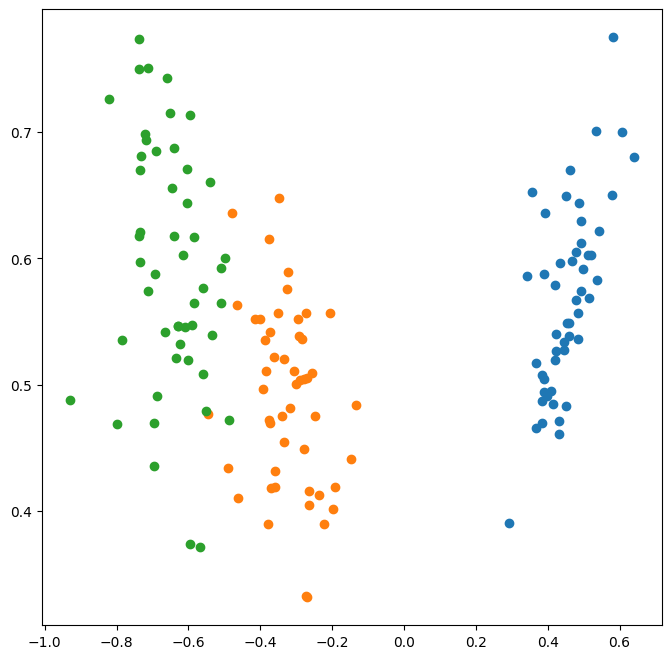

In [39]:
import numpy as np
from sklearn.datasets import load_iris
from scipy.linalg import eigh
#============================================================
class LDA:
    #-------------------------------------------------------
    def __init__(self,k):
        self.k = k
        self.X = None
        self.y = None
        self.val = None
        self.z = None
        self.clases = None
    #------------------------------------------------------
    def determinar_clases(self,Y):
        clases = []
        for y in Y:
            if y not in clases:
                clases.append(y)
        self.clases = clases
        self. k = len(clases)
        return clases                   # 0,1...
# id X1  X2  Clase
# 0  2   3    0
# 1  3   3    0
# 2  2   4    0
# 3  5   2    1
# 4  6   2    1   mascara = [0,1,2] clase 0
# 5  6   3    1
    #-------------------------------------------------------
    def medias_k(self,clases,X,y):
        #clases = self.clases(y)
        medias_k = [0]*len(clases)
        for i,c in enumerate(clases):
            mascara = y == c
            medias_k[i] = X[mascara].mean(axis = 0)
        return medias_k
    #------------------------------------------------------
    def dispersion_intra_clases(self,X,y,medias_k):
        m, n = X.shape
        clases = self.determinar_clases(y)
        #medias_k = medias_k(clases,X,y)
        SW = np.zeros((n,n))
        for i,c in enumerate(clases):
            xc_uc = X[y==c] - medias_k[i]
            SWc = xc_uc.T @ xc_uc
            SW +=SWc
        return SW
#
# SW = SW0 + SW1 = |1.34  -0.66|
#                  |-0.66 1.34|
    #------------------------------------------------------
    def n_s(self,clases,X,y):
        n_s = [0]*len(clases)
        for i,c in enumerate(clases):
            mascara = y ==c
            n_s[i] = len(X[mascara])
        return n_s
    #-------------------------------------------------------
    def dispersion_inter_clases(self,X,y,medias_k):
        u = X.mean(axis = 0)
        m ,n = X.shape
        SB = np.zeros((n,n))
        clases = self.determinar_clases(y)
        n_s = self.n_s(clases,X,y)
        for i,c in enumerate(clases): 
            uk_u = (medias_k[i] - u).reshape(n,1)
            SB_c = n_s[i] * uk_u @ uk_u.T
            SB +=SB_c
        return SB
# SB = SB0 + SB1 = |16.74 -5.01|
#                  |-5.01 1.5 |
    #--------------------------------------------------------
    def ordenar_indices(self,arr):
        n = len(arr)
        arr_ = arr.copy()
        inds = list(range(n))
        for i in range(n-2,-1,-1):
            e = arr_[i]
            ids = inds[i]
            j = i + 1
            while j<=n-1 and arr_[j]>e:     # [4, 2, 7, 1] ,  7 [1]
                arr_[j - 1] = arr_[j]
                inds[j - 1] = inds[j]
                j = j + 1
            arr_[j - 1] = e
            inds[j - 1] = ids
        return inds
    #--------------------------------------------------------
    def transformar_entrenar(self,X,y,normalizar='estandarizar'):
        self.X = X
        self.y = y
        clases = self.determinar_clases(y)
        medias_k = self.medias_k(clases,X,y)
        SW = self.dispersion_intra_clases(X,y,medias_k)
        SB = self.dispersion_inter_clases(X,y,medias_k)
        #val, vec = np.linalg.eig(np.linalg.inv(SW)@SB)
        val , vec = eigh(SB,SW)
        ids = self.ordenar_indices(val)
        z = X@vec[:,ids]  
        return z
    #-----------------------------------------------------
    def graficar(self,z):
        plt.figure(figsize=(8,8))
        for i,c in enumerate(self.clases):
            mascara = self.y == c
            z1 = z[mascara,0]
            z2 = z[mascara,1]
            plt.scatter(z1,z2)
        plt.show()
    #------------------------------------------------------
#=============================================================
if __name__=='__main__':
    data = load_iris()
    X, y = data.data, data.target 
    lda = LDA(k=2)
    z = lda.transformar_entrenar(X,y)
    lda.graficar(z)